# BCI Competition IV-2a — Real-Data Preprocessing + FBCSP/LASSO Audit

This notebook is the next diagnostic stage after the A01 controlled center-loss ablation. It focuses on **real EEG preprocessing, event timing, spectral quality, FBCSP/LASSO correctness, and a classical FBCSP+LDA sanity baseline** before further CRNN/FBGAN tuning.

### Run order
1. Load all 9 subjects.
2. Run the A01 event/epoch audit.
3. Run the A01 EEG quality report.
4. Run the fold-aware z-score + FBCSP/LASSO audit.
5. Run the FBCSP+LDA sanity baseline.
6. Only then run the CRNN ablation.

The Zhang et al. paper reports CRNN-DF at **63.52 ± 10.70%** and the 3,000-sample FBGAN setting at **72.82 ± 10.44%** across nine LOSO subjects.

In [1]:
# ============================================================
# CELL 1 — IMPORTS / GLOBAL CONFIGURATION
# ============================================================
# If needed, run:
# %pip install -U mne scipy scikit-learn pandas matplotlib seaborn h5py

import os
import re
import copy
import json
import math
import time
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as signal
from scipy.linalg import eigh

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LassoCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    cohen_kappa_score,
)
from sklearn.manifold import TSNE

import mne

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

SEED = 42

def reset_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_global_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("MNE:", mne.__version__)
print("Device:", device)

FS = 250
N_CHANNELS = 22
N_TIME = 1000
TRIAL_SECONDS = 4.0
CLASS_NAMES = ["Left Hand", "Right Hand", "Feet", "Tongue"]
EVENT_TO_CLASS = {769: 0, 770: 1, 771: 2, 772: 3}
EVAL_UNKNOWN_EVENT = 783

DATA_ROOT_CANDIDATES = [
    Path.cwd() / "BCI IV-2a",
    Path.cwd() / "BCI_IV-2a",
    Path.cwd() / "BCI IV 2a",
    Path.cwd().parent / "BCI IV-2a",
    Path("/Users") / os.getenv("USER", "") / "MtechProj" / "BCI IV-2a",
    Path("/content/BCI IV-2a"),
]

def find_dataset_root(candidates=DATA_ROOT_CANDIDATES):
    for p in candidates:
        if p.exists() and (p / "A01T.gdf").exists():
            return p.resolve()
    for base in [Path.cwd(), Path.home()]:
        try:
            for p in base.rglob("A01T.gdf"):
                if p.parent.name.lower().replace("_", " ") in {"bci iv-2a", "bci iv 2a"}:
                    return p.parent.resolve()
        except Exception:
            pass
    return None

DATA_ROOT = find_dataset_root()
print("DATA_ROOT =", DATA_ROOT)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not locate A01T.gdf. Set DATA_ROOT manually."
    )
TRUE_LABEL_ROOT = DATA_ROOT / "true_labels"

PyTorch: 2.10.0
MNE: 1.11.0
Device: mps
DATA_ROOT = /Users/ashokvarmabevara/MtechProj/BCI IV-2a


In [2]:

# ============================================================
# CELL 2 — DATASET FOLDER AUDIT
# ============================================================

gdf_files = sorted(DATA_ROOT.glob("A*.gdf"))
mat_files = sorted(DATA_ROOT.glob("A*.mat"))

print("Dataset directory:", DATA_ROOT)
print("GDF files:", len(gdf_files))
print("MAT files:", len(mat_files))
print("true_labels exists:", TRUE_LABEL_ROOT.exists())

for p in gdf_files:
    print(f"{p.name:10s}  {p.stat().st_size/1024/1024:7.2f} MB")

print("\nRequired GDF files:")
for sid in range(1, 10):
    for sess in ["T", "E"]:
        p = DATA_ROOT / f"A{sid:02d}{sess}.gdf"
        print(p.name, "OK" if p.exists() else "MISSING")

print("\nTrue-label files, if present:")
if TRUE_LABEL_ROOT.exists():
    for p in sorted(TRUE_LABEL_ROOT.rglob("*")):
        if p.is_file():
            print(" ", p.relative_to(TRUE_LABEL_ROOT))
else:
    print("  No true_labels directory found.")
    print("  The official BCI site provides the true labels for evaluation sets.")


Dataset directory: /Users/ashokvarmabevara/MtechProj/BCI IV-2a
GDF files: 18
MAT files: 9
true_labels exists: True
A01E.gdf      32.77 MB
A01T.gdf      32.08 MB
A02E.gdf      31.61 MB
A02T.gdf      32.30 MB
A03E.gdf      30.95 MB
A03T.gdf      31.51 MB
A04E.gdf      31.49 MB
A04T.gdf      28.67 MB
A05E.gdf      32.43 MB
A05T.gdf      32.73 MB
A06E.gdf      31.79 MB
A06T.gdf      32.39 MB
A07E.gdf      32.11 MB
A07T.gdf      32.49 MB
A08E.gdf      32.81 MB
A08T.gdf      32.21 MB
A09E.gdf      32.20 MB
A09T.gdf      32.12 MB

Required GDF files:
A01T.gdf OK
A01E.gdf OK
A02T.gdf OK
A02E.gdf OK
A03T.gdf OK
A03E.gdf OK
A04T.gdf OK
A04E.gdf OK
A05T.gdf OK
A05E.gdf OK
A06T.gdf OK
A06E.gdf OK
A07T.gdf OK
A07E.gdf OK
A08T.gdf OK
A08E.gdf OK
A09T.gdf OK
A09E.gdf OK

True-label files, if present:
  A01E.mat
  A01T.mat
  A02E.mat
  A02T.mat
  A03E.mat
  A03T.mat
  A04E.mat
  A04T.mat
  A05E.mat
  A05T.mat
  A06E.mat
  A06T.mat
  A07E.mat
  A07T.mat
  A08E.mat
  A08T.mat
  A09E.mat
  A09T.mat
  tru

In [3]:

# ============================================================
# CELL 3 — ROBUST TRUE-LABEL LOADER FOR E-SESSIONS
# ============================================================

def _flatten_numeric_arrays(obj):
    out = []
    if isinstance(obj, np.ndarray):
        if np.issubdtype(obj.dtype, np.number):
            out.append(np.asarray(obj).ravel())
        elif obj.dtype == object:
            for item in obj.ravel():
                out.extend(_flatten_numeric_arrays(item))
    elif isinstance(obj, dict):
        for v in obj.values():
            out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            out.extend(_flatten_numeric_arrays(item))
    return out

def _candidate_label_files(subject_id):
    # Example subject_id: "A01"
    candidates = []
    if not TRUE_LABEL_ROOT.exists():
        return candidates

    for p in TRUE_LABEL_ROOT.rglob("*"):
        if not p.is_file():
            continue
        name = p.name.lower()
        full = str(p).lower()
        if subject_id.lower() in name or subject_id.lower() in full:
            if p.suffix.lower() in {".mat", ".txt", ".csv", ".tsv", ".npy"}:
                candidates.append(p)

    # Also allow files named only A01E...
    candidates.sort()
    return candidates

def _load_numeric_label_vector(path):
    suffix = path.suffix.lower()

    if suffix in {".txt", ".csv", ".tsv"}:
        arr = np.loadtxt(path, delimiter="," if suffix == ".csv" else None)
        return np.asarray(arr).ravel()

    if suffix == ".npy":
        return np.asarray(np.load(path)).ravel()

    if suffix == ".mat":
        mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
        candidates = _flatten_numeric_arrays(mat)

        valid = []
        for arr in candidates:
            arr = np.asarray(arr).ravel()
            if arr.size >= 100:
                # Typical BCI 2a class labels are 1..4.
                vals = np.unique(arr[np.isfinite(arr)])
                if vals.size > 0 and np.all(np.isin(vals, [0, 1, 2, 3, 4])):
                    valid.append(arr)

        if not valid:
            raise ValueError(f"No plausible 1..4 label vector found in {path}")

        valid.sort(key=lambda x: x.size, reverse=True)
        return valid[0]

    raise ValueError(f"Unsupported label file: {path}")

def load_true_labels_for_eval(subject_id, expected_n=288):
    files = _candidate_label_files(subject_id)
    if not files:
        raise FileNotFoundError(
            f"No true label file found for {subject_id}E inside {TRUE_LABEL_ROOT}. "
            "Download the official BCI IV-2a evaluation labels and place them there."
        )

    last_error = None
    for path in files:
        try:
            y = _load_numeric_label_vector(path)
            y = np.asarray(y).astype(int)

            # Some label files can contain 0..3; others 1..4.
            vals = set(np.unique(y).tolist())
            if vals.issubset({0,1,2,3}) and len(vals) == 4:
                y = y
            elif vals.issubset({1,2,3,4}):
                y = y - 1
            else:
                continue

            if len(y) == expected_n:
                print(f"{subject_id}E labels loaded from {path.name}: {len(y)}")
                return y

        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"Could not find a valid {expected_n}-label vector for {subject_id}E. "
        f"Candidates: {[p.name for p in files]}. Last error: {last_error}"
    )


In [4]:

# ============================================================
# CELL 4 — GDF READER: CONTINUOUS 1–38 Hz + EVENT TIMING
# ============================================================
TRIAL_START_CODE = 768

def _parse_event_code(description):
    nums = re.findall(r"\d+", str(description))
    return int(nums[-1]) if nums else None

def _fill_continuous_nans(eeg):
    eeg = np.asarray(eeg, dtype=np.float32).copy()
    for ch in range(eeg.shape[0]):
        row = eeg[ch]
        bad = ~np.isfinite(row)
        if bad.any():
            finite = row[np.isfinite(row)]
            row[bad] = float(np.mean(finite)) if finite.size else 0.0
    return eeg

def _continuous_bandpass_1_38(eeg, fs=FS, order=5):
    sos = signal.butter(order, [1.0, 38.0], btype="bandpass", fs=fs, output="sos")
    return signal.sosfiltfilt(sos, eeg, axis=-1).astype(np.float32)

def _extract_annotation_events(raw):
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    code_by_mne_id = {eid: _parse_event_code(desc) for desc, eid in event_id.items()}
    parsed = []
    for sample, _, event_eid in events:
        code = code_by_mne_id.get(event_eid)
        if code is not None:
            parsed.append((int(sample), int(code)))
    if not parsed:
        for ann in raw.annotations:
            onset_sample = int(round(float(ann["onset"]) * float(raw.info["sfreq"])))
            code = _parse_event_code(ann["description"])
            if code is not None:
                parsed.append((onset_sample, code))
    return sorted(parsed, key=lambda z: z[0])

def read_gdf_trials(path, session_type):
    path = Path(path)
    raw = mne.io.read_raw_gdf(str(path), preload=True, verbose="ERROR")
    data = raw.get_data()
    if data.shape[0] < 22:
        raise ValueError(f"{path.name}: expected >=22 channels, got {data.shape[0]}")
    sfreq = float(raw.info["sfreq"])
    if not np.isclose(sfreq, FS):
        raise ValueError(f"{path.name}: expected {FS} Hz, got {sfreq}")

    eeg = _continuous_bandpass_1_38(_fill_continuous_nans(data[:22]), fs=FS, order=5)
    parsed = _extract_annotation_events(raw)
    selected_codes = set(EVENT_TO_CLASS) if session_type.upper()=="T" else {EVAL_UNKNOWN_EVENT}
    selected = [(sample, code) for sample, code in parsed if code in selected_codes]
    if not selected:
        raise RuntimeError(f"{path.name}: no expected cue events found; codes={sorted(set(c for _,c in parsed))}")

    X, y, meta_rows = [], [], []
    for trial_idx, (cue_sample, code) in enumerate(selected):
        stop = cue_sample + N_TIME
        if stop > eeg.shape[1]:
            continue
        X.append(eeg[:, cue_sample:stop].astype(np.float32))
        if session_type.upper()=="T":
            y.append(EVENT_TO_CLASS[code])
        prev_starts = [s for s,c in parsed if c==TRIAL_START_CODE and s <= cue_sample]
        trial_start = prev_starts[-1] if prev_starts else None
        cue_delay = (cue_sample-trial_start)/sfreq if trial_start is not None else np.nan
        meta_rows.append({"file":path.name,"session":session_type.upper(),"trial_in_file":trial_idx,
                          "cue_sample":cue_sample,"event_code":code,"trial_start_sample":trial_start,
                          "cue_delay_seconds":cue_delay,"epoch_end_sample":stop})
    return (np.asarray(X,dtype=np.float32),
            np.asarray(y,dtype=np.int64) if session_type.upper()=="T" else None,
            pd.DataFrame(meta_rows))


In [5]:

# ============================================================
# CELL 5 — LOAD ALL 9 SUBJECTS / BOTH SESSIONS
# ============================================================

def load_subject(subject_num):
    sid = f"A{subject_num:02d}"

    # Training/calibration session: labels are present in GDF events.
    X_T, y_T, meta_T = read_gdf_trials(DATA_ROOT / f"{sid}T.gdf", "T")

    # Evaluation session: cue onset is unknown, labels come from official true labels.
    X_E, _, meta_E = read_gdf_trials(DATA_ROOT / f"{sid}E.gdf", "E")
    y_E = load_true_labels_for_eval(sid, expected_n=len(X_E))

    if len(X_T) != 288:
        print(f"WARNING {sid}T: expected 288 trials, got {len(X_T)}")
    if len(X_E) != 288:
        print(f"WARNING {sid}E: expected 288 trials, got {len(X_E)}")

    # Merge sessions in file order: T then E.
    X = np.concatenate([X_T, X_E], axis=0)
    y = np.concatenate([y_T, y_E], axis=0)

    meta_T["subject"] = sid
    meta_E["subject"] = sid
    meta_T["source_session"] = "T"
    meta_E["source_session"] = "E"

    meta = pd.concat([meta_T, meta_E], ignore_index=True)

    assert X.shape[1:] == (N_CHANNELS, N_TIME)
    assert len(X) == len(y)

    return X, y, meta

subjects = {}
load_log = []

for s in range(1, 10):
    t0 = time.time()
    Xs, ys, ms = load_subject(s)
    subjects[f"A{s:02d}"] = {"X": Xs, "y": ys, "meta": ms}
    load_log.append({
        "subject": f"A{s:02d}",
        "trials": len(Xs),
        "shape": str(Xs.shape),
        "seconds": round(time.time() - t0, 2),
    })
    print(
        f"A{s:02d}: X={Xs.shape}, class_counts={np.bincount(ys)}, "
        f"time={load_log[-1]['seconds']}s"
    )

load_df = pd.DataFrame(load_log)
display(load_df)

X_all = np.stack([subjects[f"A{s:02d}"]["X"] for s in range(1, 10)], axis=0)
y_all = np.stack([subjects[f"A{s:02d}"]["y"] for s in range(1, 10)], axis=0)

print("\nFINAL STACKED DATA")
print("X_all:", X_all.shape)  # expected (9, 576, 22, 1000)
print("y_all:", y_all.shape)  # expected (9, 576)


A01E labels loaded from A01E.mat: 288
A01: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.3s
A02E labels loaded from A02E.mat: 288
A02: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.12s
A03E labels loaded from A03E.mat: 288
A03: X=(576, 22, 1000), class_counts=[144 144 144 144], time=0.99s
A04E labels loaded from A04E.mat: 288
A04: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.03s
A05E labels loaded from A05E.mat: 288
A05: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.11s
A06E labels loaded from A06E.mat: 288
A06: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.08s
A07E labels loaded from A07E.mat: 288
A07: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.08s
A08E labels loaded from A08E.mat: 288
A08: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.11s
A09E labels loaded from A09E.mat: 288
A09: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.1s


,subject,trials,shape,seconds
0,A01,576,"(576, 22, 1000)",1.30
1,A02,576,"(576, 22, 1000)",1.12
2,A03,576,"(576, 22, 1000)",0.99
3,A04,576,"(576, 22, 1000)",1.03
4,A05,576,"(576, 22, 1000)",1.11
5,A06,576,"(576, 22, 1000)",1.08
6,A07,576,"(576, 22, 1000)",1.08
7,A08,576,"(576, 22, 1000)",1.11
8,A09,576,"(576, 22, 1000)",1.10



FINAL STACKED DATA
X_all: (9, 576, 22, 1000)
y_all: (9, 576)


## A01 real-data sanity audit

Run these diagnostics before CRNN training.

In [6]:

# ============================================================
# CELL 6 — EVENT / EPOCH TIMING AUDIT
# ============================================================
def audit_event_timing(subject_id="A01"):
    for sess in ["T","E"]:
        path = DATA_ROOT / f"{subject_id}{sess}.gdf"
        _, _, meta = read_gdf_trials(path, sess)
        print(f"\n{path.name}: {len(meta)} epochs")
        print("event codes:", meta["event_code"].value_counts().sort_index().to_dict())
        vals = meta["cue_delay_seconds"].dropna().to_numpy()
        if len(vals):
            print(f"cue delay from preceding 768: median={np.median(vals):.4f}s min={np.min(vals):.4f}s max={np.max(vals):.4f}s")
        dur = (meta["epoch_end_sample"].iloc[0]-meta["cue_sample"].iloc[0])/FS
        print(f"epoch duration={dur:.3f}s")
        display(meta.head(6))
    print("\nExpected: 1000 samples = 4.000 seconds from cue onset.")

audit_event_timing("A01")



A01T.gdf: 288 epochs
event codes: {769: 72, 770: 72, 771: 72, 772: 72}
cue delay from preceding 768: median=2.0000s min=2.0000s max=2.0000s
epoch duration=4.000s


,file,session,trial_in_file,cue_sample,event_code,trial_start_sample,cue_delay_seconds,epoch_end_sample
0,A01T.gdf,T,0,92368,772,91868,2.0,93368
1,A01T.gdf,T,1,94371,771,93871,2.0,95371
2,A01T.gdf,T,2,96289,770,95789,2.0,97289
3,A01T.gdf,T,3,98241,769,97741,2.0,99241
4,A01T.gdf,T,4,100249,769,99749,2.0,101249
5,A01T.gdf,T,5,102360,770,101860,2.0,103360



A01E.gdf: 288 epochs
event codes: {783: 288}
cue delay from preceding 768: median=2.0000s min=2.0000s max=2.0000s
epoch duration=4.000s


,file,session,trial_in_file,cue_sample,event_code,trial_start_sample,cue_delay_seconds,epoch_end_sample
0,A01E.gdf,E,0,106840,783,106340,2.0,107840
1,A01E.gdf,E,1,108843,783,108343,2.0,109843
2,A01E.gdf,E,2,110761,783,110261,2.0,111761
3,A01E.gdf,E,3,112713,783,112213,2.0,113713
4,A01E.gdf,E,4,114721,783,114221,2.0,115721
5,A01E.gdf,E,5,116832,783,116332,2.0,117832



Expected: 1000 samples = 4.000 seconds from cue onset.


In [7]:

# ============================================================
# CELL 7 — REAL EEG QUALITY REPORT (A01)
# ============================================================
CHANNEL_NAMES = ["Fz","FC3","FC1","FCz","FC2","FC4","C5","C3","C1","Cz","C2","C4","C6","CP3","CP1","CPz","CP2","CP4","P3","P1","Pz","P2"]

def eeg_quality_report(X, y=None):
    X = np.asarray(X, dtype=np.float32)
    print("X:", X.shape, "finite:", np.isfinite(X).mean())
    stats = pd.DataFrame({
        "channel": CHANNEL_NAMES,
        "ptp": np.ptp(X, axis=(0,2)),
        "rms": np.sqrt(np.mean(X**2, axis=(0,2))),
        "variance": np.var(X, axis=(0,2)),
    }).sort_values("variance", ascending=False)
    display(stats.round(6))

    bands=[(1,4),(4,8),(8,12),(12,16),(16,20),(20,24),(24,28),(28,32),(32,35),(35,38)]
    rows=[]
    for lo,hi in bands:
        sos=signal.butter(5,[lo,hi],btype="bandpass",fs=FS,output="sos")
        xb=signal.sosfiltfilt(sos,X,axis=-1)
        p=np.mean(xb**2,axis=(0,2))
        rows.append({"band":f"{lo}-{hi} Hz",**{CH:p[i] for i,CH in enumerate(CHANNEL_NAMES)}})
    band_df=pd.DataFrame(rows).set_index("band")
    print("\nBand power:")
    display(band_df.round(6))
    print("\nC3/Cz/C4 band power:")
    display(band_df[["C3","Cz","C4"]].round(6))
    if y is not None:
        print("class counts:", np.bincount(np.asarray(y).astype(int), minlength=4))
    return stats,band_df

a01_stats,a01_band_power=eeg_quality_report(subjects["A01"]["X"], subjects["A01"]["y"])


X: (576, 22, 1000) finite: 1.0


,channel,ptp,rms,variance
3,FCz,0.000099,0.000009,0.0
9,Cz,0.000101,0.000009,0.0
4,FC2,0.000101,0.000009,0.0
2,FC1,0.000104,0.000009,0.0
0,Fz,0.000118,0.000009,0.0
10,C2,0.000100,0.000009,0.0
15,CPz,0.000101,0.000009,0.0
5,FC4,0.000108,0.000009,0.0
8,C1,0.000093,0.000009,0.0
16,CP2,0.000101,0.000009,0.0



Band power:


,Fz,FC3,FC1,FCz,FC2,FC4,C5,C3,C1,Cz,...,C6,CP3,CP1,CPz,CP2,CP4,P3,P1,Pz,P2
band,,,,,,,,,,,,,,,,,,,,,
1-4 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4-8 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8-12 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12-16 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16-20 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20-24 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24-28 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28-32 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32-35 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



C3/Cz/C4 band power:


,C3,Cz,C4
band,,,
1-4 Hz,0.0,0.0,0.0
4-8 Hz,0.0,0.0,0.0
8-12 Hz,0.0,0.0,0.0
12-16 Hz,0.0,0.0,0.0
16-20 Hz,0.0,0.0,0.0
20-24 Hz,0.0,0.0,0.0
24-28 Hz,0.0,0.0,0.0
28-32 Hz,0.0,0.0,0.0
32-35 Hz,0.0,0.0,0.0


class counts: [144 144 144 144]


## Fold-aware preprocessing

Training statistics are fit using A02–A09 only for the A01 audit.

In [8]:

# ============================================================
# CELL 8 — FOLD-AWARE PREPROCESSOR + Z-SCORE AUDIT
# ============================================================
class EEGPreprocessorReal:
    def __init__(self, fs=250, order=5):
        self.fs=fs; self.order=order
        self.bands=[(1,4),(4,8),(8,12),(12,16),(16,20),(20,24),(24,28),(28,32),(32,35),(35,38)]
        self.mu=None; self.sigma=None
    @staticmethod
    def _fill_nans(X):
        X=np.asarray(X,dtype=np.float32).copy()
        ch_mean=np.nanmean(X,axis=(0,2),keepdims=True); ch_mean=np.where(np.isfinite(ch_mean),ch_mean,0.0)
        bad=~np.isfinite(X)
        if bad.any(): X[bad]=np.broadcast_to(ch_mean,X.shape)[bad]
        return X
    def fit(self,X):
        X=self._fill_nans(X)
        self.mu=np.mean(X,axis=(0,2),keepdims=True).astype(np.float32)
        self.sigma=(np.std(X,axis=(0,2),keepdims=True)+1e-6).astype(np.float32)
        return self
    def transform_1_38(self,X):
        if self.mu is None: raise RuntimeError("Call fit first")
        return ((self._fill_nans(X)-self.mu)/self.sigma).astype(np.float32)
    def transform(self,X):
        Xn=self.transform_1_38(X)
        Xfb=np.stack([signal.sosfiltfilt(signal.butter(self.order,[lo,hi],btype="bandpass",fs=self.fs,output="sos"),Xn,axis=-1).astype(np.float32) for lo,hi in self.bands],axis=1)
        return Xn,Xfb
    def audit_zscore(self,X_train,X_test):
        a=self.transform_1_38(X_train); b=self.transform_1_38(X_test)
        df=pd.DataFrame({"channel":CHANNEL_NAMES,
                         "train_mean":np.mean(a,axis=(0,2)),"train_std":np.std(a,axis=(0,2)),
                         "test_mean":np.mean(b,axis=(0,2)),"test_std":np.std(b,axis=(0,2))})
        display(df.round(4))
        print("max |train mean|:",float(np.max(np.abs(df.train_mean))))
        print("max |train std-1|:",float(np.max(np.abs(df.train_std-1.0))))
        return df


In [9]:

# ============================================================
# CELL 9 — FBCSP + LASSO AUDIT
# ============================================================
class FBCSPLassoReal:
    def __init__(self,m_filters=4,max_iter=5000,random_state=42):
        self.m_filters=m_filters; self.max_iter=max_iter; self.random_state=random_state
        self.bands=[(1,4),(4,8),(8,12),(12,16),(16,20),(20,24),(24,28),(28,32),(32,35),(35,38)]
        self.W_full=None; self.selected_indices=None; self.Var=None; self.candidate_table=None; self.selection_table=None; self.lasso_alpha=None
    @staticmethod
    def _norm_cov(x):
        c=x@x.T; tr=np.trace(c)
        return c/tr if np.isfinite(tr) and tr>1e-12 else np.eye(x.shape[0])/x.shape[0]
    def fit(self,X_fb,y):
        X_fb=np.asarray(X_fb,dtype=np.float32); y=np.asarray(y).astype(int)
        if X_fb.shape[1:] != (10,22,X_fb.shape[-1]):
            raise ValueError(f"Expected (N,10,22,T), got {X_fb.shape}")
        W_all=[]; feat_all=[]; rows=[]; gi=0
        for b,(lo,hi) in enumerate(self.bands):
            Xb=X_fb[:,b]; filters=[]
            for c in range(4):
                Xc=Xb[y==c]; Xr=Xb[y!=c]
                Rc=np.mean([self._norm_cov(x) for x in Xc],axis=0); Rr=np.mean([self._norm_cov(x) for x in Xr],axis=0)
                vals,vecs=eigh(Rc+1e-8*np.eye(22),Rr+1e-8*np.eye(22)); order=np.argsort(vals)[::-1]; vals=vals[order]; vecs=vecs[:,order]
                filters.append(vecs[:,:self.m_filters])
                for j in range(self.m_filters):
                    rows.append({"global_index":gi,"band":f"{lo}-{hi} Hz","band_index":b,"ovr_class":CLASS_NAMES[c],"csp_rank":j+1,"eigenvalue":float(vals[j])})
                    gi+=1
            Wb=np.hstack(filters); W_all.append(Wb)
            Z=np.einsum("cf,nct->nft",Wb,Xb); v=np.var(Z,axis=-1); p=v/(np.sum(v,axis=1,keepdims=True)+1e-12); feat_all.append(np.log(p+1e-12))
        self.W_full=np.stack(W_all); F=np.concatenate(feat_all,axis=1); self.candidate_table=pd.DataFrame(rows)
        lasso=LassoCV(alphas=np.logspace(-4,-1,25),cv=5,max_iter=self.max_iter,n_jobs=-1,random_state=self.random_state).fit(F,y.astype(float))
        self.lasso_alpha=float(lasso.alpha_); coef=np.abs(lasso.coef_); threshold=max(1e-8,float(np.max(coef))*1e-6)
        sel=np.flatnonzero(coef>threshold)
        if len(sel)==0: sel=np.argsort(coef)[-16:]
        self.selected_indices=np.sort(sel); self.Var=len(sel)
        self.candidate_table["lasso_coef"]=lasso.coef_; self.candidate_table["abs_coef"]=coef; self.candidate_table["selected"]=False
        self.candidate_table.loc[self.selected_indices,"selected"]=True; self.selection_table=self.candidate_table[self.candidate_table.selected].copy()
        print(f"FBCSP+LASSO: 160 candidates -> {self.Var} selected")
        print(f"LASSO alpha: {self.lasso_alpha:.6g}")
        return self
    def transform_all160(self,X_fb):
        out=[]
        for b in range(X_fb.shape[1]):
            W=self.W_full[b]; Z=np.einsum("cf,nct->nft",W,X_fb[:,b]); v=np.var(Z,axis=-1); p=v/(np.sum(v,axis=1,keepdims=True)+1e-12); out.append(np.log(p+1e-12))
        return np.concatenate(out,axis=1)
    def transform(self,X_fb):
        return self.transform_all160(X_fb)[:,self.selected_indices]

def show_fbcsp_selection_report(fbcsp):
    print("\nSELECTED FEATURES")
    display(fbcsp.selection_table[["global_index","band","ovr_class","csp_rank","eigenvalue","lasso_coef","abs_coef"]].sort_values("global_index").round(6))
    print("\nSelected per frequency band")
    display(fbcsp.selection_table.groupby(["band_index","band"]).size().reset_index(name="selected_count"))
    print("\nSelected per OVR class")
    display(fbcsp.selection_table.groupby("ovr_class").size().reset_index(name="selected_count"))
    print("\nAll 160 candidates")
    display(fbcsp.candidate_table[["global_index","band","ovr_class","csp_rank","eigenvalue","abs_coef","selected"]].round(6))


train: (4608, 22, 1000) test: (576, 22, 1000) filter-bank train: (4608, 10, 22, 1000)


,channel,train_mean,train_std,test_mean,test_std
0,Fz,0.0,0.9078,-0.0017,0.8321
1,FC3,-0.0,0.8993,-0.0014,0.8428
2,FC1,-0.0,0.9055,-0.0017,0.8553
3,FCz,0.0,0.9102,-0.0015,0.8512
4,FC2,0.0,0.9078,-0.0010,0.8460
5,FC4,0.0,0.9051,-0.0003,0.8296
6,C5,0.0,0.8795,-0.0005,0.8070
7,C3,-0.0,0.8987,-0.0011,0.8074
8,C1,0.0,0.9037,-0.0012,0.8391
9,Cz,0.0,0.9091,-0.0012,0.8494


max |train mean|: 1.683386230411088e-08
max |train std-1|: 0.12054872512817383
FBCSP+LASSO: 160 candidates -> 14 selected
LASSO alpha: 0.0421697

SELECTED FEATURES


,global_index,band,ovr_class,csp_rank,eigenvalue,lasso_coef,abs_coef
0,0,1-4 Hz,Left Hand,1,1.170260,-0.099290,0.099290
33,33,8-12 Hz,Left Hand,2,1.181051,-0.059878,0.059878
35,35,8-12 Hz,Left Hand,4,1.142894,-0.067110,0.067110
40,40,8-12 Hz,Feet,1,1.239273,0.044791,0.044791
44,44,8-12 Hz,Tongue,1,1.372996,0.463545,0.463545
62,62,12-16 Hz,Tongue,3,1.184390,0.036895,0.036895
65,65,16-20 Hz,Left Hand,2,1.090938,-0.041289,0.041289
66,66,16-20 Hz,Left Hand,3,1.078038,-0.055757,0.055757
67,67,16-20 Hz,Left Hand,4,1.065023,-0.020840,0.020840
70,70,16-20 Hz,Right Hand,3,1.092899,-0.027384,0.027384



Selected per frequency band


...


Selected per OVR class


,ovr_class,selected_count
0,Feet,1
1,Left Hand,8
2,Right Hand,2
3,Tongue,3



All 160 candidates


,global_index,band,ovr_class,csp_rank,eigenvalue,abs_coef,selected
0,0,1-4 Hz,Left Hand,1,1.170260,0.09929,True
1,1,1-4 Hz,Left Hand,2,1.137502,0.00000,False
2,2,1-4 Hz,Left Hand,3,1.103832,0.00000,False
3,3,1-4 Hz,Left Hand,4,1.088119,0.00000,False
4,4,1-4 Hz,Right Hand,1,1.235166,0.00000,False
...,...,...,...,...,...,...,...
155,155,35-38 Hz,Feet,4,1.078701,0.00000,False
156,156,35-38 Hz,Tongue,1,1.368660,0.00000,False
157,157,35-38 Hz,Tongue,2,1.226411,0.00000,False
158,158,35-38 Hz,Tongue,3,1.130529,0.00000,False



A01 FBCSP+LDA: accuracy=33.51% | balanced=33.51% | kappa=0.1134


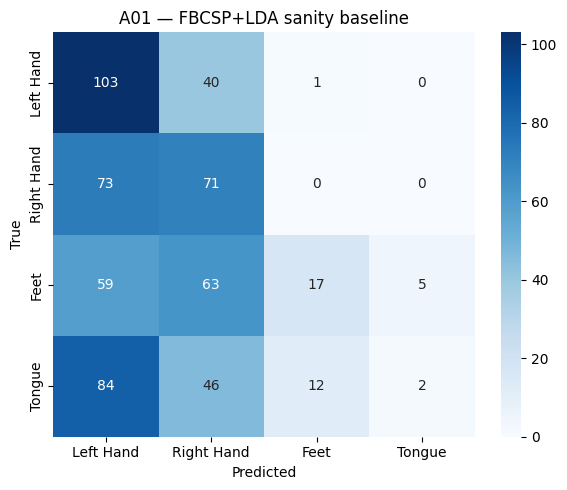

In [10]:

# ============================================================
# CELL 10 — A01 FOLD + FBCSP/LDA SANITY BASELINE
# ============================================================
def prepare_a01_audit_fold():
    train_ids=[f"A{i:02d}" for i in range(1,10) if f"A{i:02d}"!="A01"]
    Xtr=np.concatenate([subjects[s]["X"] for s in train_ids],axis=0); ytr=np.concatenate([subjects[s]["y"] for s in train_ids],axis=0)
    Xte=subjects["A01"]["X"]; yte=subjects["A01"]["y"]
    pre=EEGPreprocessorReal(fs=FS); pre.fit(Xtr)
    Xtrn,Xtrfb=pre.transform(Xtr); Xten,Xtefb=pre.transform(Xte)
    print("train:",Xtrn.shape,"test:",Xten.shape,"filter-bank train:",Xtrfb.shape)
    z=pre.audit_zscore(Xtr,Xte)
    fbcsp=FBCSPLassoReal(m_filters=4).fit(Xtrfb,ytr); show_fbcsp_selection_report(fbcsp)
    Ftr=fbcsp.transform_all160(Xtrfb); Fte=fbcsp.transform_all160(Xtefb); Ftrs=Ftr[:,fbcsp.selected_indices]; Ftes=Fte[:,fbcsp.selected_indices]
    lda=LinearDiscriminantAnalysis(solver="lsqr",shrinkage="auto").fit(Ftrs,ytr); pred=lda.predict(Ftes)
    acc=accuracy_score(yte,pred); bal=balanced_accuracy_score(yte,pred); k=cohen_kappa_score(yte,pred)
    print(f"\nA01 FBCSP+LDA: accuracy={acc*100:.2f}% | balanced={bal*100:.2f}% | kappa={k:.4f}")
    cm=confusion_matrix(yte,pred,labels=np.arange(4)); plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES); plt.title("A01 — FBCSP+LDA sanity baseline"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()
    return {"X_train":Xtrn,"y_train":ytr,"X_test":Xten,"y_test":yte,"X_train_fb":Xtrfb,"X_test_fb":Xtefb,"pre":pre,"z_audit":z,"fbcsp":fbcsp,"F_train":Ftr,"F_test":Fte,"F_train_sel":Ftrs,"F_test_sel":Ftes,"lda":lda,"lda_pred":pred,"lda_accuracy":acc}

# RUN THIS FIRST:
a01_audit=prepare_a01_audit_fold()


## CRNN stage after the audit

The CRNN still receives the normalized 22×1000 EEG. FBCSP/LASSO is audited separately.

In [ ]:
# ============================================================
# CELL 8 — CRNN-DF + CONTROLLED CENTER-LOSS VARIANTS
# ============================================================

class CRNNDF(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv = nn.Conv2d(1, 45, kernel_size=(22,45), stride=(1,1))
        self.bn = nn.BatchNorm2d(45)
        self.dropout1 = nn.Dropout(0.5)
        self.pool = nn.MaxPool2d(kernel_size=(1,75), stride=(1,10))
        self.lstm1 = nn.LSTM(input_size=45, hidden_size=64, batch_first=True)
        self.dropout2 = nn.Dropout(0.5)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=64, batch_first=True)
        self.dropout3 = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn(self.conv(x)))
        x = self.dropout1(x)
        x = self.pool(x)
        x = x.squeeze(2).permute(0,2,1)
        x, _ = self.lstm1(x)
        x = self.dropout2(x)
        x, _ = self.lstm2(x)
        x = self.dropout3(x)
        features = x[:, -1, :]
        logits = self.fc(features)
        return logits, features

class DiscriminativeCenterLoss(nn.Module):
    """
    Three modes:
      none         : lambda=0, no center term
      fixed_shift  : initialize centroids once, then apply paper-style
                     centroid separation every 15 epochs
      dynamic      : initialize centroids once, update class centers from
                     the current training feature space after each epoch,
                     then apply the same centroid-shift rule every 15 epochs.

    The dynamic mode is an engineering variant for ablation, not a claim of
    exact source-code replication of the paper.
    """
    def __init__(self, num_classes=4, feat_dim=64, alpha=0.02,
                 lambda_cen=0.1, mode="fixed_shift"):
        super().__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.alpha = alpha
        self.lambda_cen = lambda_cen
        self.mode = mode
        self.register_buffer("centroids", torch.zeros(num_classes, feat_dim))
        self.ce = nn.CrossEntropyLoss()

    @torch.no_grad()
    def initialize_from_features(self, features, y):
        for c in range(self.num_classes):
            m = (y == c)
            if m.any():
                self.centroids[c].copy_(features[m].mean(dim=0))

    @torch.no_grad()
    def update_from_features(self, features, y):
        for c in range(self.num_classes):
            m = (y == c)
            if m.any():
                self.centroids[c].copy_(features[m].mean(dim=0))

    @torch.no_grad()
    def shift_centroids(self):
        center = self.centroids.mean(0, keepdim=True)
        delta = self.centroids - center
        norm = torch.linalg.norm(delta, dim=1, keepdim=True).clamp_min(1e-8)
        self.centroids += self.alpha * delta / norm

    def forward(self, features, y, logits):
        ce = self.ce(logits, y)
        if self.lambda_cen <= 0.0 or self.mode == "none":
            cen = torch.zeros((), device=features.device)
            return ce, ce, cen
        centers = self.centroids[y]
        cen = ((features - centers) ** 2).sum(dim=1).mean()
        total = ce + self.lambda_cen * cen
        return total, ce, cen

In [ ]:
# ============================================================
# CELL 9 — DETERMINISTIC TRAINING / EVALUATION UTILITIES
# ============================================================

def make_loader(X, y, batch_size=32, shuffle=True, seed=SEED):
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    yt = torch.tensor(y, dtype=torch.long)
    ds = torch.utils.data.TensorDataset(Xt, yt)
    gen = torch.Generator()
    gen.manual_seed(seed)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=gen if shuffle else None,
        num_workers=0,
        pin_memory=False,
    )

@torch.no_grad()
def extract_all_features(model, X, y, batch_size=128):
    model.eval()
    loader = make_loader(X, y, batch_size=batch_size, shuffle=False)
    feats, labels = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        _, fb = model(xb)
        feats.append(fb.detach().cpu())
        labels.append(yb)
    return torch.cat(feats, dim=0).to(device), torch.cat(labels, dim=0).to(device)

def train_crnn_df(
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-4,
    patience=None,
    center_lambda=0.1,
    center_mode="fixed_shift",
    center_alpha=0.02,
    center_shift_every=15,
    seed=SEED,
):
    # Reset EVERYTHING that controls initialization/order for each ablation.
    reset_global_seed(seed)

    init_loader = make_loader(X_train, y_train, batch_size=128, shuffle=False)
    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True, seed=seed)

    model = CRNNDF(num_classes=4).to(device)

    center_loss = DiscriminativeCenterLoss(
        num_classes=4,
        feat_dim=64,
        alpha=center_alpha,
        lambda_cen=center_lambda,
        mode=center_mode,
    ).to(device)

    # Initialize centroids once from the untrained feature space.
    init_features, init_labels = extract_all_features(model, X_train, y_train)
    center_loss.initialize_from_features(init_features, init_labels)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running = {"loss": 0.0, "ce": 0.0, "cen": 0.0}
        n_batches = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits, feats = model(xb)
            loss, ce, cen = center_loss(feats, yb, logits)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            running["loss"] += float(loss.item())
            running["ce"] += float(ce.item())
            running["cen"] += float(cen.item())
            n_batches += 1

        # Dynamic variant: recalculate centers from current training features.
        if center_mode == "dynamic" and center_lambda > 0:
            current_features, current_labels = extract_all_features(model, X_train, y_train)
            center_loss.update_from_features(current_features, current_labels)

        # Paper-style centroid separation step.
        if center_lambda > 0 and center_mode != "none" and epoch % center_shift_every == 0:
            center_loss.shift_centroids()

        rec = {
            "epoch": epoch,
            "loss": running["loss"] / max(1, n_batches),
            "ce": running["ce"] / max(1, n_batches),
            "cen": running["cen"] / max(1, n_batches),
        }

        if X_val is not None and y_val is not None:
            val_acc = evaluate_model(model, X_val, y_val)["accuracy"]
            rec["val_acc"] = val_acc

        history.append(rec)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            extra = f" | val={rec['val_acc']*100:.2f}%" if "val_acc" in rec else ""
            print(
                f"Epoch {epoch:03d} | loss={rec['loss']:.4f} | "
                f"CE={rec['ce']:.4f} | CEN={rec['cen']:.4f}{extra}"
            )

    return model, pd.DataFrame(history)

@torch.no_grad()
def evaluate_model(model, X, y):
    model.eval()
    loader = make_loader(X, y, batch_size=128, shuffle=False)
    all_pred, all_feat, all_true = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits, feats = model(xb)
        all_pred.append(logits.argmax(1).cpu().numpy())
        all_feat.append(feats.cpu().numpy())
        all_true.append(yb.numpy())
    y_pred = np.concatenate(all_pred)
    feats = np.concatenate(all_feat)
    y_true = np.concatenate(all_true)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred,
        "features": feats,
    }

def plot_fold_result(result, subject_id, title_suffix=""):
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=np.arange(4))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=True, ax=axes[0],
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    )
    axes[0].set_title(f"{subject_id} — Confusion Matrix{title_suffix}")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    feats = result["features"]
    perplexity = min(30, max(5, len(feats)//20))
    z = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, init="pca").fit_transform(feats)
    axes[1].scatter(z[:,0], z[:,1], c=result["y_true"], cmap="viridis", s=14)
    axes[1].set_title(f"{subject_id} — CRNN-DF Feature t-SNE{title_suffix}")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

In [ ]:

# ============================================================
# CELL 13 — A01 CRNN ABLATION AFTER PREPROCESSING/FBCSP AUDIT
# ============================================================
def run_a01_after_audit(epochs=150,seed=SEED):
    if 'a01_audit' not in globals():
        raise RuntimeError("Run: a01_audit=prepare_a01_audit_fold() first.")
    fold=a01_audit; configs=[{"name":"CRNN-only","lambda":0.0,"mode":"none"},{"name":"CRNN + dynamic centers","lambda":0.1,"mode":"dynamic"}]
    rows=[]; outputs={}
    for cfg in configs:
        print("\n"+"#"*80); print(cfg["name"].upper()); print("#"*80)
        reset_global_seed(seed)
        model,history=train_crnn_df(fold["X_train"],fold["y_train"],epochs=epochs,batch_size=32,lr=1e-4,weight_decay=1e-4,patience=None,center_lambda=cfg["lambda"],center_mode=cfg["mode"],center_alpha=0.02,center_shift_every=15,seed=seed)
        te=evaluate_model(model,fold["X_test"],fold["y_test"]); tr=evaluate_model(model,fold["X_train"],fold["y_train"])
        rows.append({"variant":cfg["name"],"test_accuracy":te["accuracy"],"balanced_accuracy":te["balanced_accuracy"],"kappa":te["kappa"],"train_accuracy":tr["accuracy"]})
        outputs[cfg["name"]]={"model":model,"history":history,"test":te,"train":tr}; plot_fold_result(te,"A01",title_suffix=f" — {cfg['name']}")
    summary=pd.DataFrame(rows).sort_values("test_accuracy",ascending=False).reset_index(drop=True)
    display(summary.assign(test_accuracy_pct=lambda d:d.test_accuracy*100,train_accuracy_pct=lambda d:d.train_accuracy*100))
    print("\nUse the FBCSP+LDA result as the first gate:")
    print("1) Weak FBCSP+LDA -> fix EEG/CSP.")
    print("2) Strong FBCSP+LDA but weak CRNN -> inspect CRNN input/optimization.")
    return summary,outputs

# RUN ONLY AFTER THE AUDIT:
# a01_summary,a01_outputs=run_a01_after_audit(epochs=150,seed=SEED)


In [ ]:

# ============================================================
# CELL 14 — FULL 9-SUBJECT STRICT LOSO (DISABLED)
# ============================================================
RUN_FULL_LOSO=False
LOSO_EPOCHS=150
SELECTED_CENTER_MODE="dynamic"
SELECTED_CENTER_LAMBDA=0.1

if RUN_FULL_LOSO:
    print("Enable only after A01 audit and baseline are credible.")
else:
    print("RUN_FULL_LOSO=False — finish the A01 preprocessing/FBCSP audit first.")


## FBGAN intentionally disabled

Do not start FBGAN until the strict CRNN baseline is credible. The paper uses 3,000 generated samples per target subject, 750 per class. fileciteturn3file4L271-L305